# Run postprocessing


In [ ]:
import pandas as pd

output_directory = "../output"
# run_directory = "run_2026_07_21__08_59_49"
# run_directory = "run_2026_07_21__10_53_48"
run_directory = "run_2026_07_21__19_50_25"

episodes = pd.read_csv(f"{output_directory}/{run_directory}/episodes.csv")

# reference: 64x64, gamma 0.99, lr: 0.0005/0.001, no target network

episodes

,index,episode_time,steps,noise,episode_reward,avg_critic_loss,avg_actor_loss
0,0,2.383332,143,0.393165,28.760174,3.525205,-0.043034
1,1,2.299999,138,0.386650,20.226154,5.366306,-0.216289
2,2,2.249999,135,0.380397,-7.173418,3.346412,-0.236999
3,3,1.833332,110,0.375387,-4.392662,6.008502,-0.094664
4,4,2.066665,124,0.369831,4.855179,4.730558,-0.262674
...,...,...,...,...,...,...,...
2120,2120,26.933094,1616,0.050000,232.383530,7.073018,-178.696530
2121,2121,8.383377,503,0.050000,1310.153000,7.855961,-175.784880
2122,2122,9.666691,580,0.050000,1031.110200,6.307840,-176.435560
2123,2123,4.316668,259,0.050000,249.944750,3.990859,-174.464540


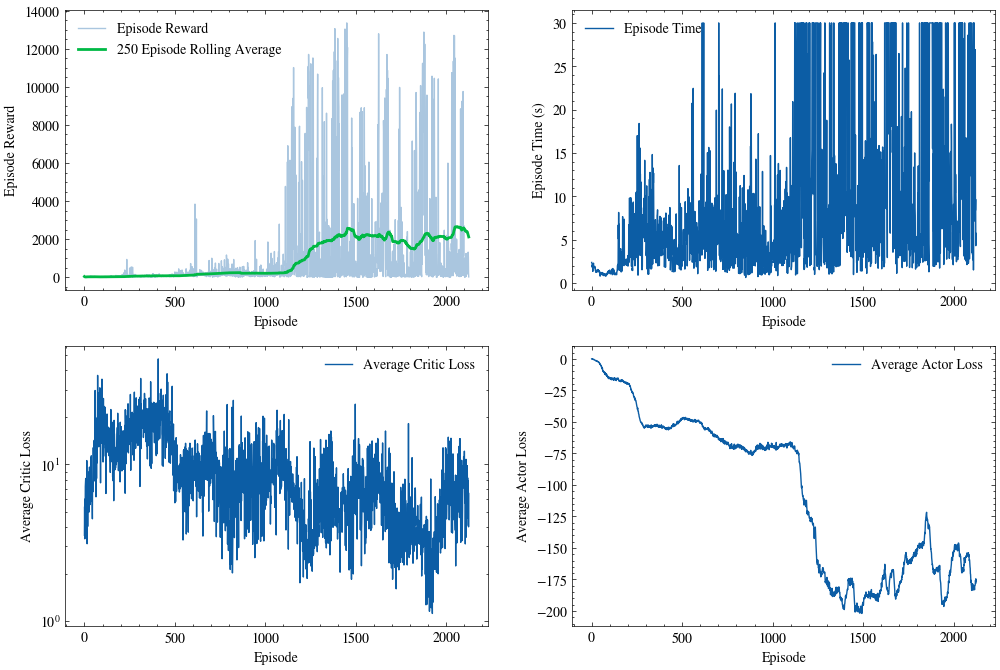

In [741]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(
    episodes["index"], episodes["episode_reward"], label="Episode Reward", alpha=0.35
)
plt.plot(
    episodes["index"],
    episodes["episode_reward"].rolling(window=250, min_periods=1).mean(),
    label="250 Episode Rolling Average",
    linewidth=2,
)
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(episodes["index"], episodes["episode_time"], label="Episode Time")
plt.xlabel("Episode")
plt.ylabel("Episode Time (s)")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(episodes["index"], episodes["avg_critic_loss"], label="Average Critic Loss")
plt.xlabel("Episode")
plt.ylabel("Average Critic Loss")
plt.yscale("log")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episodes["index"], episodes["avg_actor_loss"], label="Average Actor Loss")
plt.xlabel("Episode")
plt.ylabel("Average Actor Loss")
plt.legend()

plt.show()

## State component distributions

Distribution of the raw (un-normalized) state components logged over the whole run
(`states.csv`). Use these to choose normalization scales: with `normalize(v) = tanh(v / scale)`,
a good `scale` maps the bulk of the distribution into roughly `[-1, 1]` without saturating
`tanh`. A reasonable rule of thumb is `scale ≈ 99th-percentile magnitude` (dotted red lines),
which places that percentile at `tanh(1) ≈ 0.76`.


In [742]:
import numpy as np

states = pd.read_csv(f"{output_directory}/{run_directory}/states.csv")

# Per-component summary that directly informs scale selection.
summary = states.describe(percentiles=[0.01, 0.5, 0.99]).T[
    ["mean", "std", "min", "1%", "50%", "99%", "max"]
]
# Suggested scale: the larger of the |1%| / |99%| percentile magnitudes.
summary["suggested_scale"] = np.maximum(
    states.quantile(0.99).abs(), states.quantile(0.01).abs()
)
print(summary)

components = list(states.columns)
ncols = 3
nrows = -(-len(components) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, components):
    data = states[col].to_numpy()
    ax.hist(data, bins=100, color="tab:blue", alpha=0.8)
    ax.axvline(data.mean(), color="k", linestyle="--", linewidth=1, label="mean")
    lo, hi = np.percentile(data, [1, 99])
    ax.axvline(lo, color="tab:red", linestyle=":", linewidth=1, label="1% / 99%")
    ax.axvline(hi, color="tab:red", linestyle=":", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("count")
    ax.set_yscale("log")

# Hide any unused axes in the grid.
for ax in axes[len(components) :]:
    ax.set_visible(False)

axes[0].legend(fontsize="small")
fig.suptitle("Raw (un-normalized) state component distributions", y=1.0)
fig.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../output/run_2026_07_21__19_29_15/states.csv'